# Evaluacion Parcial N1 - Fundamentos de Deep Learning
## Clasificacion de prendas de vestir con una Red Neuronal Multicapa (MLP) sobre Fashion-MNIST

**Asignatura:** DLY0100 Deep Learning
**Dataset:** Fashion-MNIST (Keras)
**Arquitectura:** Red Neuronal Artificial Multicapa (MLP)
**Frameworks:** TensorFlow / Keras


## 1. Introduccion

### 1.1 Descripcion del problema
Fashion-MNIST es un dataset de imagenes de prendas de vestir en escala de grises de 28x28 pixeles,
con 10 clases: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.
Contiene 60.000 imagenes de entrenamiento y 10.000 de prueba. Es un reemplazo directo de MNIST
pero mas dificil, usado como benchmark de algoritmos de clasificacion.

### 1.2 Objetivo
Implementar una **red neuronal artificial multicapa (MLP)** en Python usando **TensorFlow/Keras**
para clasificar correctamente las 10 categorias. El trabajo incluye:

1. Carga y preprocesamiento de los datos.
2. Definicion, entrenamiento y ajuste de un MLP con distintas funciones de activacion,
   optimizadores y tasas de aprendizaje.
3. Aplicacion de tecnicas de regularizacion (Dropout, L2, Batch Normalization) para combatir
   sobreajuste.
4. Evaluacion del desempeño con metricas accuracy, precision, recall y F1-score.
5. Comparacion de distintas configuraciones y seleccion de la mejor.

### 1.3 Relacion con la teoria vista en clase
Se aplican conceptos de: Perceptron y MLP, redes Fully Connected Feed-Forward,
Backpropagation, Descenso del Gradiente, funciones de activacion (sigmoid, tanh, relu, softmax),
funciones de error (categorical_crossentropy), generalizacion vs sobreajuste,
tecnicas de regularizacion (L2, dropout, early stopping, batch normalization),
inicializacion de parametros (Xavier/He) y optimizadores (SGD, Adam, RMSprop).


## 2. Librerias

In [ ]:
# Librerias base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.datasets import fashion_mnist

# Scikit-learn para metricas y split
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,balanced_accuracy_score,
                             f1_score, classification_report, confusion_matrix)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)


TensorFlow: 2.19.0
Keras: 3.13.2


## 3. Carga de datos

Fashion-MNIST viene incluido en Keras. Se obtienen ya separados en train (60.000) y test (10.000).


In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

print('x_train_full:', x_train_full.shape, 'dtype:', x_train_full.dtype)
print('y_train_full:', y_train_full.shape, 'dtype:', y_train_full.dtype)
print('x_test      :', x_test.shape)
print('y_test      :', y_test.shape)
print('Rango de pixeles: min =', x_train_full.min(), '| max =', x_train_full.max())
print('Clases unicas:', np.unique(y_train_full))


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train_full: (60000, 28, 28) dtype: uint8
y_train_full: (60000,) dtype: uint8
x_test      : (10000, 28, 28)
y_test      : (10000,)
Rango de pixeles: min = 0 | max = 255
Clases unicas: [0 1 2 3 4 5 6 7 8 9]


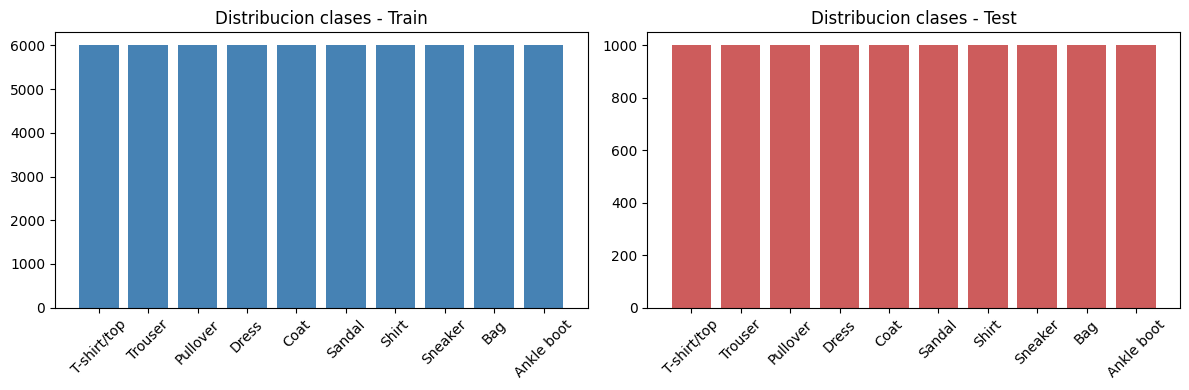

Dataset balanceado: cada clase tiene 6000 muestras en train y 1000 en test.


In [ ]:
# Nombres oficiales de las clases (Fashion-MNIST)
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Distribucion de clases
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

counts_train = np.bincount(y_train_full)
counts_test  = np.bincount(y_test)

ax[0].bar(class_names, counts_train, color='steelblue')
ax[0].set_title('Distribucion clases - Train')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(class_names, counts_test, color='indianred')
ax[1].set_title('Distribucion clases - Test')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Dataset balanceado: cada clase tiene', counts_train[0], 'muestras en train y',
      counts_test[0], 'en test.')


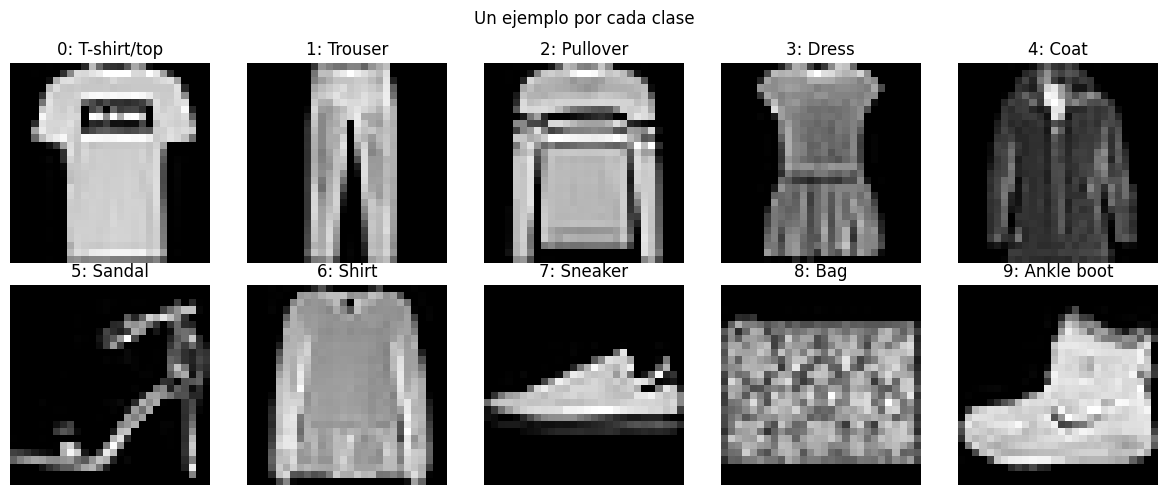

In [ ]:
# Ejemplos visuales de cada clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_full == i)[0][0]
    ax.imshow(x_train_full[idx], cmap='gray')
    ax.set_title(f'{i}: {class_names[i]}')
    ax.axis('off')
plt.suptitle('Un ejemplo por cada clase')
plt.tight_layout()
plt.show()


## 4. Preprocesamiento

Decisiones tomadas y justificacion:

1. **Normalizacion a [0,1]**: se divide cada pixel por 255. Esto evita que algunas
   dimensiones dominen el descenso del gradiente y permite converger mas rapido
   (visto en *1.5.1 Tecnicas de Regularizacion - Escalar valores de entrada*).
2. **Flatten 28x28 -> 784**: un MLP recibe vectores planos, no matrices 2D. Por eso
   cada imagen se vectoriza a 784 neuronas de entrada.
3. **One-hot encoding de las etiquetas**: el problema es multiclase (10 clases) y
   usaremos `categorical_crossentropy` con capa de salida `softmax`, que espera
   etiquetas en formato one-hot.
4. **Validation split del 20% sobre el train original**: usamos 48.000 para entrenar
   y 12.000 para validar en cada epoca. El test (10.000) se reserva solo para la
   evaluacion final.


In [ ]:
# 4.1 Normalizar pixeles a [0,1]
x_train_full_norm = x_train_full.astype('float32') / 255.0
x_test_norm       = x_test.astype('float32') / 255.0

# 4.2 Aplanar imagenes 28x28 -> 784
N_FEATURES = 28 * 28
x_train_flat = x_train_full_norm.reshape(-1, N_FEATURES)
x_test_flat  = x_test_norm.reshape(-1, N_FEATURES)

# 4.3 One-hot encoding de las etiquetas
NUM_CLASSES = 10
y_train_full_oh = keras.utils.to_categorical(y_train_full, NUM_CLASSES)
y_test_oh       = keras.utils.to_categorical(y_test, NUM_CLASSES)

# 4.4 Split train/validation 80/20
X_train, X_val, y_train, y_val = train_test_split(
    x_train_flat, y_train_full_oh,
    test_size=0.20, random_state=SEED, stratify=y_train_full
)

# Labels no-one-hot (utiles para metricas)
y_train_lbl = np.argmax(y_train, axis=1)
y_val_lbl   = np.argmax(y_val,   axis=1)
y_test_lbl  = y_test.copy()

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_val  :', X_val.shape,   '| y_val  :', y_val.shape)
print('X_test :', x_test_flat.shape, '| y_test :', y_test_oh.shape)
print('Rango X_train:', X_train.min(), '-', X_train.max())


X_train: (48000, 784) | y_train: (48000, 10)
X_val  : (12000, 784) | y_val  : (12000, 10)
X_test : (10000, 784) | y_test : (10000, 10)
Rango X_train: 0.0 - 1.0


## 5. Definicion del modelo MLP base

### 5.1 Arquitectura
Red Fully Connected Feed-Forward con la siguiente estructura:

- Capa de entrada: 784 neuronas (pixeles aplanados)
- Capa oculta 1: 128 neuronas, activacion **ReLU**
- Capa oculta 2: 64 neuronas, activacion **ReLU**
- Capa de salida: 10 neuronas, activacion **Softmax**

### 5.2 Funciones justificadas
- **ReLU en ocultas**: evita el desvanecimiento del gradiente que sufren sigmoid/tanh
  en redes profundas (visto en *1.6.1 Desvanecimiento y Explosion del Gradiente*).
  Inicializacion **He** que es la recomendada para ReLU (visto en *1.5.1*).
- **Softmax en salida**: convierte los logits en una distribucion de probabilidad sobre
  las 10 clases. Es la eleccion natural para clasificacion multiclase exclusiva.
- **Perdida `categorical_crossentropy`**: compatible con softmax + etiquetas one-hot.
  Penaliza fuertemente predicciones seguras pero equivocadas.
- **Optimizador Adam**: combina momentum y RMSprop con lr adaptativo. Converge mas
  rapido que SGD puro en la mayoria de casos (visto en *1.6.2 Optimizadores*).

### 5.3 Hiperparametros base
- Epocas: 30 (con EarlyStopping patience=8)
- Batch size: 128
- Tasa de aprendizaje: default del optimizador (Adam=0.001)

### 5.4 Justificacion de los hiperparametros base
- **Batch size 128**: es el valor estandar usado en la literatura y tutoriales oficiales de
  Keras/TensorFlow para MNIST y Fashion-MNIST. Con 48.000 muestras de train produce
  48000/128 = 375 pasos de gradiente por epoca, lo que permite un aprendizaje efectivo
  y ademas introduce ruido util como efecto regularizador. En el experimento 4 comparamos
  contra batches mas grandes para validar empiricamente esta eleccion.
- **30 epocas con EarlyStopping**: Fashion-MNIST con MLP converge tipicamente entre la
  epoca 15 y 25. Dejamos un margen de 30 y un EarlyStopping con patience=8 para cortar
  automaticamente cuando la val_loss deje de mejorar, evitando sobreajuste y tiempo innecesario.
- **lr = 1e-3 (Adam default)**: punto medio sano; en el experimento 5 comparamos contra
  1e-4 y 1e-2 para confirmar.


In [ ]:
def build_mlp(hidden_units=(128, 64),
              activation='relu',
              out_activation='softmax',
              input_dim=784,
              num_classes=10,
              kernel_init='he_normal',
              l2_lambda=0.0,
              dropout_rate=0.0,
              use_batchnorm=False,
              name='MLP'):
    """Construye un MLP parametrizable."""
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=(input_dim,)))
    for i, units in enumerate(hidden_units):
        model.add(layers.Dense(units,
                               activation=None if use_batchnorm else activation,
                               kernel_initializer=kernel_init,
                               kernel_regularizer=reg,
                               name=f'dense_{i+1}'))
        if use_batchnorm:
            model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
            model.add(layers.Activation(activation, name=f'act_{i+1}'))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f'dropout_{i+1}'))
    model.add(layers.Dense(num_classes, activation=out_activation, name='output'))
    return model


# Hiperparametros base
EPOCHS        = 30
BATCH_SIZE    = 128
ES_PATIENCE   = 8   # early stopping patience

model_base = build_mlp(name='MLP_Base')
model_base.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
model_base.summary()


Model: "MLP_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

En dense_1 existen 128 neuronas
en dense 2 existen 64 neuronas
y en output (salida) existen 10 neuronas


El modelo base posee mas de 100.000 parámetros

### 5.4 Entrenamiento del modelo base

In [ ]:
early_base = callbacks.EarlyStopping(monitor='val_loss',
                                    patience=ES_PATIENCE,
                                    restore_best_weights=True)

hist_base = model_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_base],
    verbose=0
)
print('Entrenamiento base completado en',
      len(hist_base.history['loss']), 'epocas (corte por EarlyStopping o fin).')
print('Ultima loss train :', hist_base.history['loss'][-1])
print('Ultima loss val   :', hist_base.history['val_loss'][-1])
print('Ultima acc train  :', hist_base.history['accuracy'][-1])
print('Ultima acc val    :', hist_base.history['val_accuracy'][-1])


Entrenamiento base completado en 16 epocas (corte por EarlyStopping o fin).
Ultima loss train : 0.1967002898454666
Ultima loss val   : 0.3632863759994507
Ultima acc train  : 0.926687479019165
Ultima acc val    : 0.8889999985694885


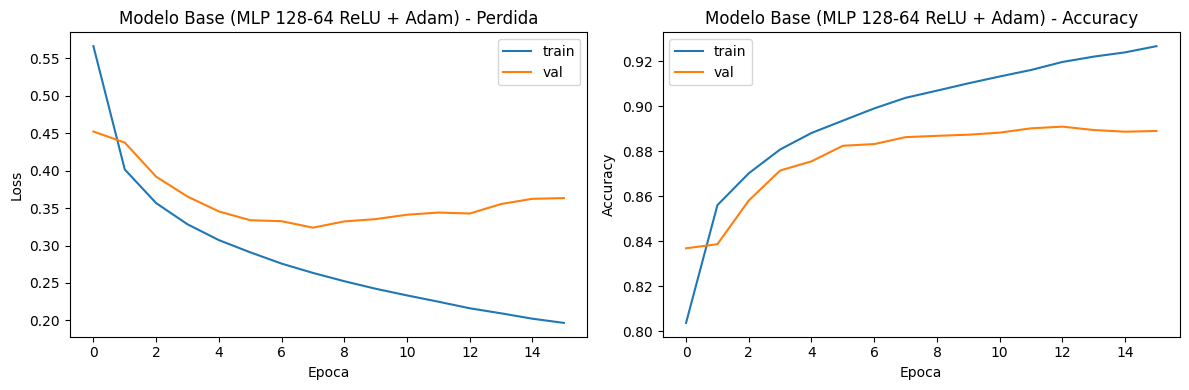

In [ ]:
def plot_history(hist, title='Modelo'):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.history['loss'],     label='train')
    ax[0].plot(hist.history['val_loss'], label='val')
    ax[0].set_title(f'{title} - Perdida')
    ax[0].set_xlabel('Epoca'); ax[0].set_ylabel('Loss'); ax[0].legend()

    ax[1].plot(hist.history['accuracy'],     label='train')
    ax[1].plot(hist.history['val_accuracy'], label='val')
    ax[1].set_title(f'{title} - Accuracy')
    ax[1].set_xlabel('Epoca'); ax[1].set_ylabel('Accuracy'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(hist_base, 'Modelo Base (MLP 128-64 ReLU + Adam)')


## 6. Helper de experimentacion

Para comparar configuraciones de forma justa y reproducible usamos una funcion
que entrena un modelo con hiperparametros dados y devuelve metricas sobre el
conjunto de validacion.


In [ ]:
def train_and_eval(config, X_tr=X_train, y_tr=y_train,
                   X_vl=X_val, y_vl=y_val, verbose=0):
    """Entrena un MLP segun `config` y devuelve dict con resultados."""
    tf.keras.utils.set_random_seed(SEED)

    model = build_mlp(
        hidden_units = config.get('hidden_units', (128, 64)),
        activation   = config.get('activation', 'relu'),
        kernel_init  = config.get('kernel_init', 'he_normal'),
        l2_lambda    = config.get('l2_lambda', 0.0),
        dropout_rate = config.get('dropout_rate', 0.0),
        use_batchnorm= config.get('use_batchnorm', False),
        name         = config['name']
    )

    opt_name = config.get('optimizer', 'adam')
    lr       = config.get('lr', None)
    if lr is not None:
        if opt_name == 'adam':
            opt = keras.optimizers.Adam(learning_rate=lr)
        elif opt_name == 'sgd':
            opt = keras.optimizers.SGD(learning_rate=lr)
        elif opt_name == 'rmsprop':
            opt = keras.optimizers.RMSprop(learning_rate=lr)
        else:
            opt = opt_name
    else:
        opt = opt_name

    model.compile(optimizer=opt, loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # EarlyStopping por defecto en todos los experimentos para evitar tiempo innecesario
    patience = config.get('es_patience', ES_PATIENCE)
    cbs = [callbacks.EarlyStopping(monitor='val_loss',
                                   patience=patience,
                                   restore_best_weights=True)]

    hist = model.fit(X_tr, y_tr,
                     validation_data=(X_vl, y_vl),
                     epochs=config.get('epochs', EPOCHS),
                     batch_size=config.get('batch_size', BATCH_SIZE),
                     callbacks=cbs, verbose=verbose)

    # metricas sobre validacion (multi-clase, macro)
    y_pred_prob = model.predict(X_vl, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_vl, axis=1)

    return {
        'name'      : config['name'],
        'config'    : config,
        'model'     : model,
        'history'   : hist,
        'accuracy'  : accuracy_score(y_true, y_pred),
        'precision' : precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'    : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1'        : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_accuracy':balanced_accuracy_score(y_true, y_pred),
        'val_loss'  : hist.history['val_loss'][-1],
        'train_loss': hist.history['loss'][-1]
    }


def results_to_df(results):
    rows = []
    for r in results:
        rows.append({
            'modelo'   : r['name'],
            'accuracy' : round(r['accuracy'], 4),
            'precision': round(r['precision'], 4),
            'recall'   : round(r['recall'], 4),
            'f1'       : round(r['f1'], 4),
            'balanced_accuracy' : round(r['balanced_accuracy'], 4),
            'train_loss': round(r['train_loss'], 4),
            'val_loss' : round(r['val_loss'], 4),
        })
    return pd.DataFrame(rows)


## 7. Experimento 1 - Funciones de activacion

Se comparan **ReLU**, **Tanh** y **Sigmoid** en las capas ocultas manteniendo todos los
demas hiperparametros fijos (2 capas 128-64, Adam, 30 epocas, batch 128, EarlyStopping).

Hipotesis: ReLU debe ser mejor porque evita la saturacion del gradiente en redes
profundas. Sigmoid en redes con mas de una capa oculta tiende a tener gradientes
muy pequeños (desvanecimiento).


In [ ]:
activation_configs = [
    {'name': 'Act_ReLU',    'activation': 'relu',    'kernel_init': 'he_normal'},
    {'name': 'Act_Tanh',    'activation': 'tanh',    'kernel_init': 'glorot_normal'},
    {'name': 'Act_Sigmoid', 'activation': 'sigmoid', 'kernel_init': 'glorot_normal'},
]

results_activation = []
for cfg in activation_configs:
    print(f'Entrenando {cfg["name"]} ...')
    r = train_and_eval(cfg)
    results_activation.append(r)
    print(f'  acc={r["accuracy"]:.4f}  f1={r["f1"]:.4f}  val_loss={r["val_loss"]:.4f}')

df_act = results_to_df(results_activation)
df_act


Entrenando Act_ReLU ...
  acc=0.8862  f1=0.8867  val_loss=0.3633
Entrenando Act_Tanh ...
  acc=0.8906  f1=0.8907  val_loss=0.3266
Entrenando Act_Sigmoid ...
  acc=0.8929  f1=0.8925  val_loss=0.3150


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss
0,Act_ReLU,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633
1,Act_Tanh,0.8906,0.8910,0.8906,0.8907,0.8906,0.1822,0.3266
2,Act_Sigmoid,0.8929,0.8940,0.8929,0.8925,0.8929,0.1898,0.3150


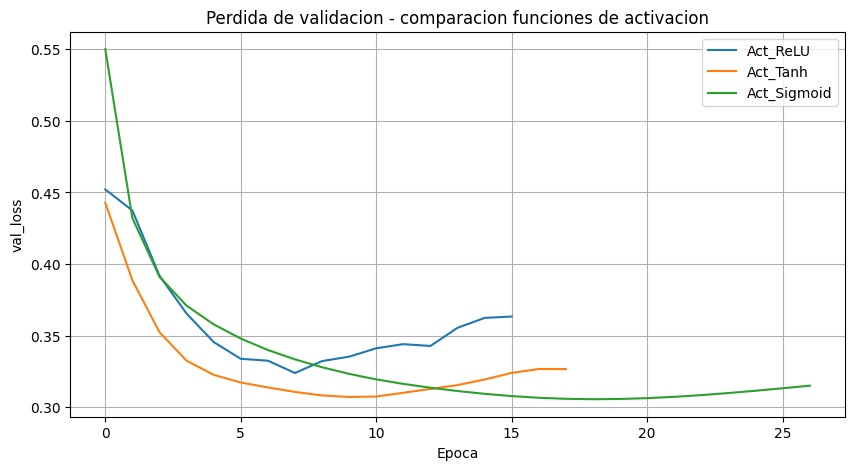

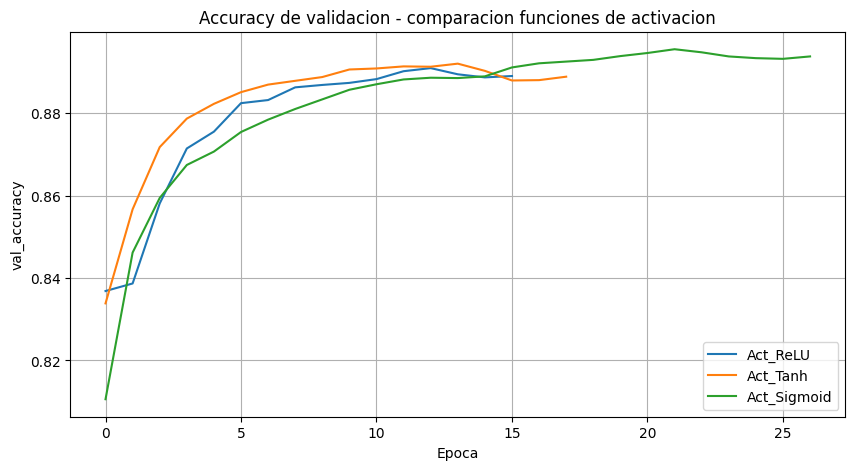

In [ ]:
# Curvas de perdida comparativas
plt.figure(figsize=(10, 5))
for r in results_activation:
    plt.plot(r['history'].history['val_loss'], label=r['name'])
plt.title('Perdida de validacion - comparacion funciones de activacion')
plt.xlabel('Epoca'); plt.ylabel('val_loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for r in results_activation:
    plt.plot(r['history'].history['val_accuracy'], label=r['name'])
plt.title('Accuracy de validacion - comparacion funciones de activacion')
plt.xlabel('Epoca'); plt.ylabel('val_accuracy'); plt.legend(); plt.grid(True)
plt.show()


## 8. Experimento 2 - Optimizadores

Se comparan **SGD**, **Adam** y **RMSprop** manteniendo el resto fijo (ReLU, 128-64).
Segun clase *1.6.2 Optimizadores*:

- **SGD** es el mas simple. Sin momentum puede estancarse en zonas planas.
- **Adam** combina momentum + lr adaptativo por parametro. Suele ser la mejor eleccion por defecto.
- **RMSprop** ajusta el lr con el promedio movil de los gradientes al cuadrado.


In [ ]:
optimizer_configs = [
    {'name': 'Opt_SGD',     'optimizer': 'sgd'},
    {'name': 'Opt_Adam',    'optimizer': 'adam'},
    {'name': 'Opt_RMSprop', 'optimizer': 'rmsprop'},
]

results_optimizer = []
for cfg in optimizer_configs:
    print(f'Entrenando {cfg["name"]} ...')
    r = train_and_eval(cfg)
    results_optimizer.append(r)
    print(f'  acc={r["accuracy"]:.4f}  f1={r["f1"]:.4f}  val_loss={r["val_loss"]:.4f}')

df_opt = results_to_df(results_optimizer)
df_opt


Entrenando Opt_SGD ...
  acc=0.8648  f1=0.8650  val_loss=0.3821
Entrenando Opt_Adam ...
  acc=0.8862  f1=0.8867  val_loss=0.3633
Entrenando Opt_RMSprop ...
  acc=0.8816  f1=0.8815  val_loss=0.4282


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss
0,Opt_SGD,0.8648,0.8706,0.8647,0.8650,0.8647,0.3486,0.3821
1,Opt_Adam,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633
2,Opt_RMSprop,0.8816,0.8876,0.8816,0.8815,0.8816,0.1689,0.4282


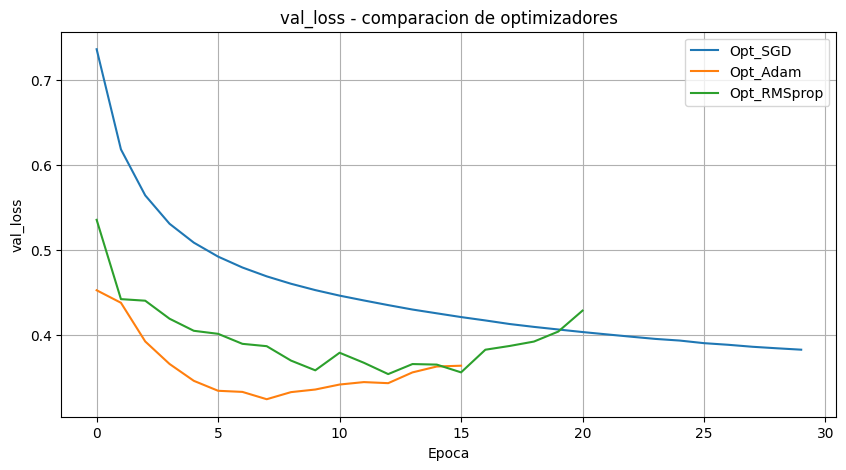

In [ ]:
plt.figure(figsize=(10, 5))
for r in results_optimizer:
    plt.plot(r['history'].history['val_loss'], label=r['name'])
plt.title('val_loss - comparacion de optimizadores')
plt.xlabel('Epoca'); plt.ylabel('val_loss'); plt.legend(); plt.grid(True)
plt.show()


## 9. Experimento 3 - Profundidad de la red

Se varia el numero de capas ocultas (2, 3 y 4) manteniendo ReLU + Adam.
El objetivo es ver si mas capas mejoran la capacidad o si aparecen problemas
de sobreajuste / desvanecimiento del gradiente.


In [ ]:
layer_configs = [
    {'name': 'Layers_2', 'hidden_units': (128, 64)},
    {'name': 'Layers_3', 'hidden_units': (128, 64, 32)},
    {'name': 'Layers_4', 'hidden_units': (256, 128, 64, 32)},
]

results_layers = []
for cfg in layer_configs:
    print(f'Entrenando {cfg["name"]} ...')
    r = train_and_eval(cfg)
    results_layers.append(r)
    print(f'  acc={r["accuracy"]:.4f}  f1={r["f1"]:.4f}  val_loss={r["val_loss"]:.4f}')

df_lay = results_to_df(results_layers)
df_lay


Entrenando Layers_2 ...
  acc=0.8862  f1=0.8867  val_loss=0.3633
Entrenando Layers_3 ...
  acc=0.8848  f1=0.8849  val_loss=0.3777
Entrenando Layers_4 ...
  acc=0.8871  f1=0.8874  val_loss=0.3493


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss
0,Layers_2,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633
1,Layers_3,0.8848,0.8852,0.8848,0.8849,0.8848,0.2077,0.3777
2,Layers_4,0.8871,0.8886,0.8871,0.8874,0.8871,0.1952,0.3493


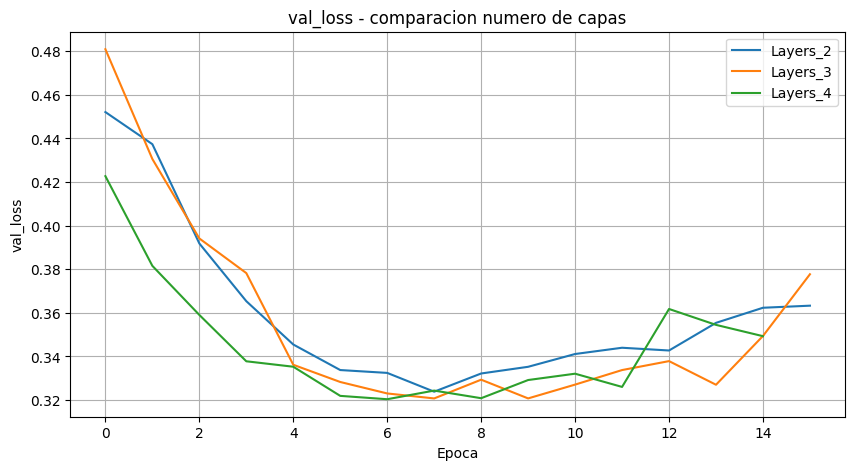

In [ ]:
plt.figure(figsize=(10, 5))
for r in results_layers:
    plt.plot(r['history'].history['val_loss'], label=r['name'])
plt.title('val_loss - comparacion numero de capas')
plt.xlabel('Epoca'); plt.ylabel('val_loss'); plt.legend(); plt.grid(True)
plt.show()


## 10. Experimento 4 - Tamaño de batch

Se varia el batch size: 128 (el valor base), 1.000 y 10.000.
Batches pequeños dan mayor ruido en el gradiente (efecto regularizador) y muchos pasos por epoca.
Batches grandes son mas estables pero necesitan mas epocas para converger porque hacen
muy pocos pasos de gradiente por epoca (con batch 10.000 sobre 48.000 muestras son solo 5 pasos).

Para que la comparacion sea justa ajustamos las epocas de manera que todos vean aproximadamente
el mismo numero total de pasos de gradiente, y dejamos EarlyStopping para cortar cuando converjan.


In [ ]:
batch_configs = [
    {'name': 'Batch_128',   'batch_size': 128,   'epochs': 30,  'es_patience': 8},
    {'name': 'Batch_1000',  'batch_size': 1000,  'epochs': 80,  'es_patience': 15},
    {'name': 'Batch_10000', 'batch_size': 10000, 'epochs': 200, 'es_patience': 30},
]

results_batch = []
for cfg in batch_configs:
    print(f'Entrenando {cfg["name"]} ...')
    r = train_and_eval(cfg)
    results_batch.append(r)
    print(f'  acc={r["accuracy"]:.4f}  f1={r["f1"]:.4f}  val_loss={r["val_loss"]:.4f}')

df_bat = results_to_df(results_batch)
df_bat


Entrenando Batch_128 ...
  acc=0.8862  f1=0.8867  val_loss=0.3633
Entrenando Batch_1000 ...
  acc=0.8860  f1=0.8841  val_loss=0.3385
Entrenando Batch_10000 ...
  acc=0.8902  f1=0.8899  val_loss=0.3160


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss
0,Batch_128,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633
1,Batch_1000,0.8860,0.8877,0.8860,0.8841,0.8860,0.1885,0.3385
2,Batch_10000,0.8902,0.8899,0.8902,0.8899,0.8902,0.1950,0.3160


## 11. Experimento 5 - Tasa de aprendizaje

Se comparan tres valores de lr con Adam: 0.0001, 0.001 (default) y 0.01.
Un lr muy bajo aprende lento y puede quedar subajustado. Un lr muy alto oscila
o diverge.


In [ ]:
lr_configs = [
    {'name': 'lr_0_0001', 'optimizer': 'adam', 'lr': 1e-4},
    {'name': 'lr_0_001',  'optimizer': 'adam', 'lr': 1e-3},
    {'name': 'lr_0_01',   'optimizer': 'adam', 'lr': 1e-2},
]

results_lr = []
for cfg in lr_configs:
    print(f'Entrenando {cfg["name"]} ...')
    r = train_and_eval(cfg)
    results_lr.append(r)
    print(f'  acc={r["accuracy"]:.4f}  f1={r["f1"]:.4f}  val_loss={r["val_loss"]:.4f}')

df_lr = results_to_df(results_lr)
df_lr


Entrenando lr_0_0001 ...
  acc=0.8859  f1=0.8859  val_loss=0.3186
Entrenando lr_0_001 ...
  acc=0.8862  f1=0.8867  val_loss=0.3633
Entrenando lr_0_01 ...
  acc=0.8708  f1=0.8711  val_loss=0.3959


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss
0,lr_0_0001,0.8859,0.8870,0.8859,0.8859,0.8859,0.2704,0.3186
1,lr_0_001,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633
2,lr_0_01,0.8708,0.8758,0.8707,0.8711,0.8708,0.2944,0.3959


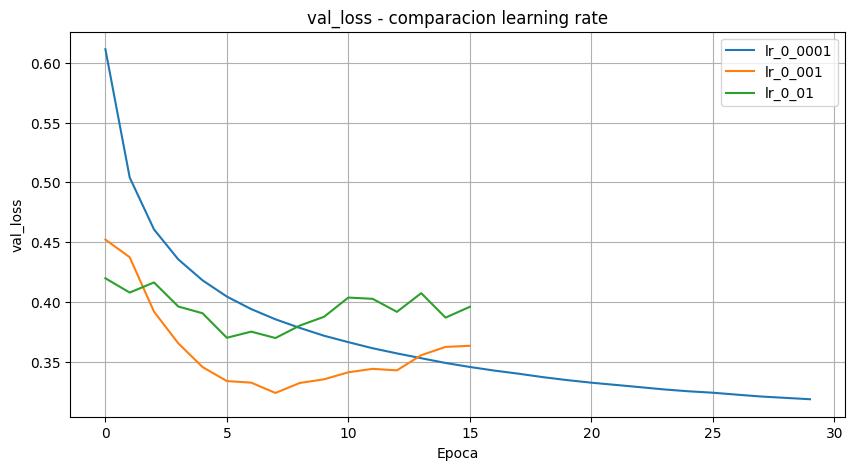

In [ ]:
plt.figure(figsize=(10, 5))
for r in results_lr:
    plt.plot(r['history'].history['val_loss'], label=r['name'])
plt.title('val_loss - comparacion learning rate')
plt.xlabel('Epoca'); plt.ylabel('val_loss'); plt.legend(); plt.grid(True)
plt.show()


## 12. Tecnicas de regularizacion y optimizacion

Se comparan tres tecnicas vistas en *1.5.1 Tecnicas de Regularizacion*:

- **Dropout 0.3**: apaga aleatoriamente el 30% de las neuronas durante training.
- **L2 (weight decay)** con lambda=0.001: penaliza pesos grandes.
- **Batch Normalization**: normaliza activaciones antes de pasar a la siguiente capa.
- **Combinado**: Dropout + L2 + BatchNorm.

El baseline es el modelo sin ninguna regularizacion.


In [ ]:
reg_configs = [
    {'name': 'Reg_None',    },
    {'name': 'Reg_Dropout', 'dropout_rate': 0.3},
    {'name': 'Reg_L2',      'l2_lambda': 1e-3},
    {'name': 'Reg_BatchNorm', 'use_batchnorm': True},
    {'name': 'Reg_All',     'dropout_rate': 0.3, 'l2_lambda': 1e-3, 'use_batchnorm': True},
]

results_reg = []
for cfg in reg_configs:
    print(f'Entrenando {cfg["name"]} ...')
    r = train_and_eval(cfg)
    results_reg.append(r)
    print(f'  acc={r["accuracy"]:.4f}  f1={r["f1"]:.4f}  val_loss={r["val_loss"]:.4f}')

df_reg = results_to_df(results_reg)
df_reg


Entrenando Reg_None ...
  acc=0.8862  f1=0.8867  val_loss=0.3633
Entrenando Reg_Dropout ...
  acc=0.8927  f1=0.8927  val_loss=0.3125
Entrenando Reg_L2 ...
  acc=0.8831  f1=0.8845  val_loss=0.4048
Entrenando Reg_BatchNorm ...
  acc=0.8712  f1=0.8721  val_loss=0.4210
Entrenando Reg_All ...
  acc=0.8766  f1=0.8757  val_loss=0.4331


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss
0,Reg_None,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633
1,Reg_Dropout,0.8927,0.8930,0.8927,0.8927,0.8927,0.2724,0.3125
2,Reg_L2,0.8831,0.8890,0.8831,0.8845,0.8831,0.3500,0.4048
3,Reg_BatchNorm,0.8712,0.8785,0.8713,0.8721,0.8712,0.1562,0.4210
4,Reg_All,0.8766,0.8786,0.8766,0.8757,0.8766,0.4453,0.4331


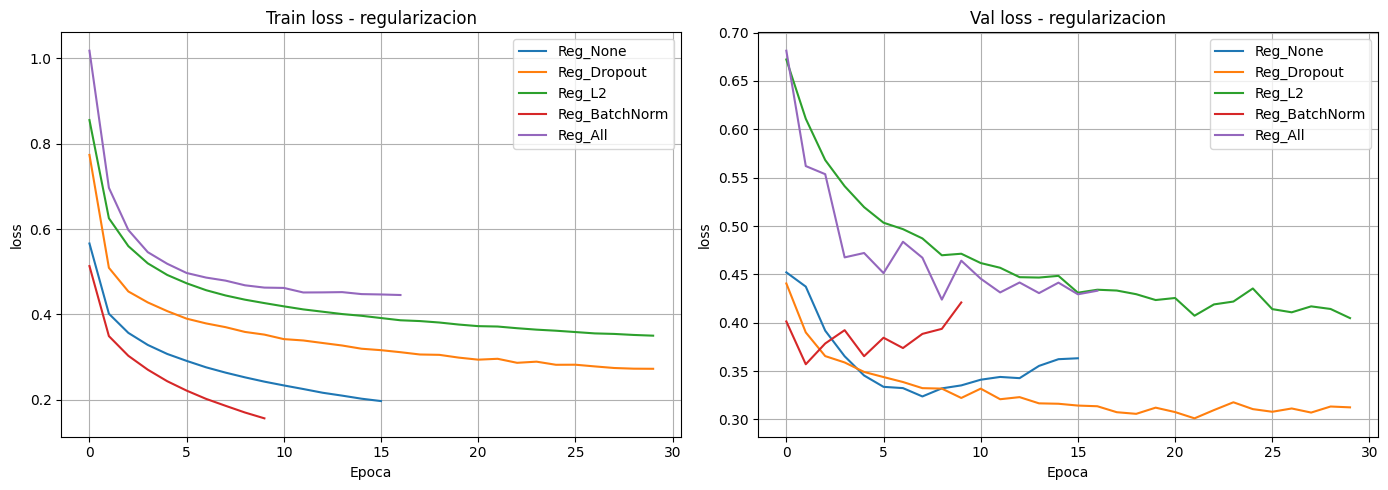

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for r in results_reg:
    ax[0].plot(r['history'].history['loss'], label=r['name'])
    ax[1].plot(r['history'].history['val_loss'], label=r['name'])
ax[0].set_title('Train loss - regularizacion')
ax[1].set_title('Val loss - regularizacion')
for a in ax:
    a.set_xlabel('Epoca'); a.set_ylabel('loss'); a.legend(); a.grid(True)
plt.tight_layout(); plt.show()


### 12.1 Gap train vs validacion (diagnostico de sobreajuste)

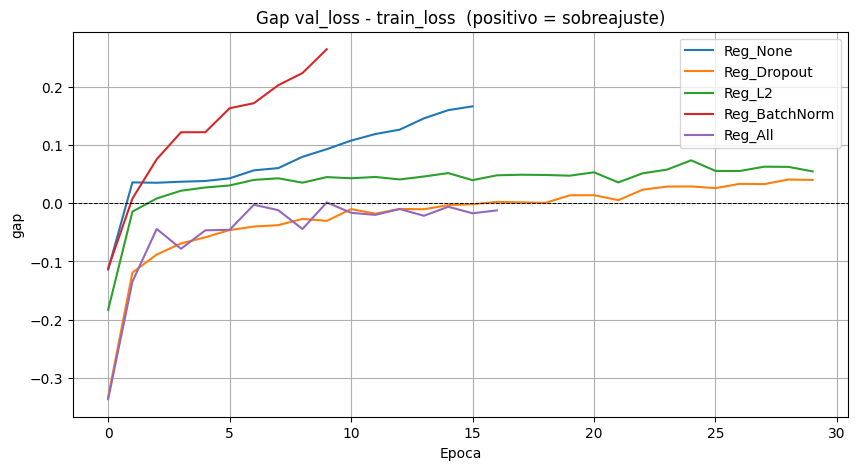

In [ ]:
plt.figure(figsize=(10, 5))
for r in results_reg:
    gap = np.array(r['history'].history['val_loss']) - np.array(r['history'].history['loss'])
    plt.plot(gap, label=r['name'])
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.title('Gap val_loss - train_loss  (positivo = sobreajuste)')
plt.xlabel('Epoca'); plt.ylabel('gap'); plt.legend(); plt.grid(True)
plt.show()


## 13. Modelo final

Con base en los experimentos anteriores, el modelo final usa la mejor combinacion
encontrada: ReLU + Adam + 2-3 capas + Dropout + (posiblemente) BatchNorm.
Se entrena sobre el **train completo (60.000)** y se evalua una unica vez sobre **test (10.000)**.


In [ ]:
# Elegir la mejor config en base a f1-score sobre validacion
all_experiments = (results_activation + results_optimizer + results_layers +
                   results_batch + results_lr + results_reg)
best = max(all_experiments, key=lambda r: r['f1'])
print('Mejor modelo segun F1 val :', best['name'])
print('  config :', best['config'])
print('  f1     :', round(best['f1'], 4))
print('  acc    :', round(best['accuracy'], 4))


Mejor modelo segun F1 val : Reg_Dropout
  config : {'name': 'Reg_Dropout', 'dropout_rate': 0.3}
  f1     : 0.8927
  acc    : 0.8927


In [ ]:
# Configuracion final propuesta
final_config = {
    'name'         : 'MLP_Final',
    'hidden_units' : (256, 128, 64),
    'activation'   : 'relu',
    'kernel_init'  : 'he_normal',
    'optimizer'    : 'adam',
    'lr'           : 1e-3,
    'dropout_rate' : 0.3,
    'l2_lambda'    : 1e-4,
    'use_batchnorm': True,
    'epochs'       : 60,
    'batch_size'   : 128,
    'early_stopping': True,
}

tf.keras.utils.set_random_seed(SEED)
model_final = build_mlp(
    hidden_units = final_config['hidden_units'],
    activation   = final_config['activation'],
    kernel_init  = final_config['kernel_init'],
    l2_lambda    = final_config['l2_lambda'],
    dropout_rate = final_config['dropout_rate'],
    use_batchnorm= final_config['use_batchnorm'],
    name         = final_config['name']
)
model_final.compile(optimizer=keras.optimizers.Adam(learning_rate=final_config['lr']),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
model_final.summary()


Model: "MLP_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

Entrenamiento final completado.
Ultima val_accuracy: 0.8758000135421753


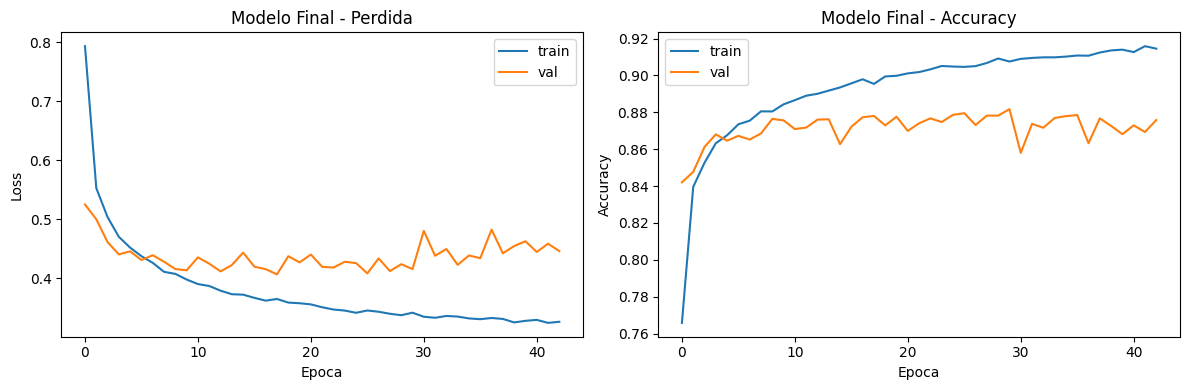

In [ ]:
# Entrenamos con train completo y validamos sobre test
early = callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                restore_best_weights=True)

hist_final = model_final.fit(
    x_train_flat, y_train_full_oh,
    validation_data=(x_test_flat, y_test_oh),
    epochs       = final_config['epochs'],
    batch_size   = final_config['batch_size'],
    callbacks    = [early],
    verbose      = 0
)
print('Entrenamiento final completado.')
print('Ultima val_accuracy:', hist_final.history['val_accuracy'][-1])
plot_history(hist_final, 'Modelo Final')


## 14. Evaluacion final sobre el conjunto de Test

Se calculan **accuracy**, **precision**, **recall** y **F1-score** (promedio macro y
por clase) sobre el test set. Tambien se grafica la **matriz de confusion**.


In [ ]:
y_test_prob = model_final.predict(x_test_flat, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

acc  = accuracy_score (y_test_lbl, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test_lbl, y_test_pred)
prec = precision_score(y_test_lbl, y_test_pred, average='macro', zero_division=0)
rec  = recall_score   (y_test_lbl, y_test_pred, average='macro', zero_division=0)
f1   = f1_score       (y_test_lbl, y_test_pred, average='macro', zero_division=0)


resumen = pd.DataFrame({
    'metrica': ['accuracy','balanced acuracy','precision (macro)','recall (macro)','f1 (macro)'],
    'valor'  : [acc,balanced_acc, prec, rec, f1]
})
print('=== Metricas globales sobre TEST ===')
print(resumen.to_string(index=False))


=== Metricas globales sobre TEST ===
          metrica    valor
         accuracy 0.878000
 balanced acuracy 0.878000
precision (macro) 0.877812
   recall (macro) 0.878000
       f1 (macro) 0.877630


In [ ]:
print('\n=== Reporte por clase ===')
print(classification_report(y_test_lbl, y_test_pred,
                            target_names=class_names, digits=4))



=== Reporte por clase ===
              precision    recall  f1-score   support

 T-shirt/top     0.8095    0.8670    0.8373      1000
     Trouser     0.9779    0.9730    0.9754      1000
    Pullover     0.7817    0.7880    0.7849      1000
       Dress     0.8781    0.8930    0.8855      1000
        Coat     0.8108    0.7670    0.7883      1000
      Sandal     0.9704    0.9520    0.9611      1000
       Shirt     0.7066    0.6790    0.6925      1000
     Sneaker     0.9133    0.9590    0.9356      1000
         Bag     0.9739    0.9710    0.9725      1000
  Ankle boot     0.9559    0.9310    0.9433      1000

    accuracy                         0.8780     10000
   macro avg     0.8778    0.8780    0.8776     10000
weighted avg     0.8778    0.8780    0.8776     10000



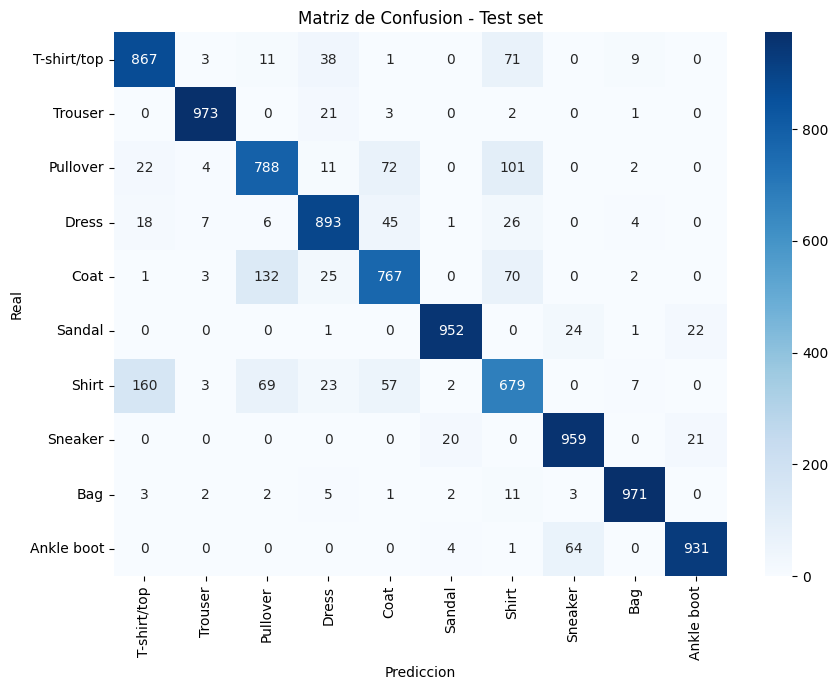

In [ ]:
# Matriz de confusion
cm = confusion_matrix(y_test_lbl, y_test_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.title('Matriz de Confusion - Test set')
plt.tight_layout(); plt.show()


### 14.1 Interpretacion
La diagonal principal concentra los aciertos. Las confusiones mas comunes en Fashion-MNIST
suelen ser entre prendas visualmente similares: T-shirt vs Shirt vs Pullover vs Coat.
Los zapatos (Sandal/Sneaker/Ankle boot) tambien se confunden entre si, mientras que
Trouser y Bag suelen tener las mejores metricas por ser visualmente mas distintivos.


## 15. Ejemplos de prediccion

Se muestran imagenes con su etiqueta real y la prediccion del modelo. Aciertos en
verde y errores en rojo.


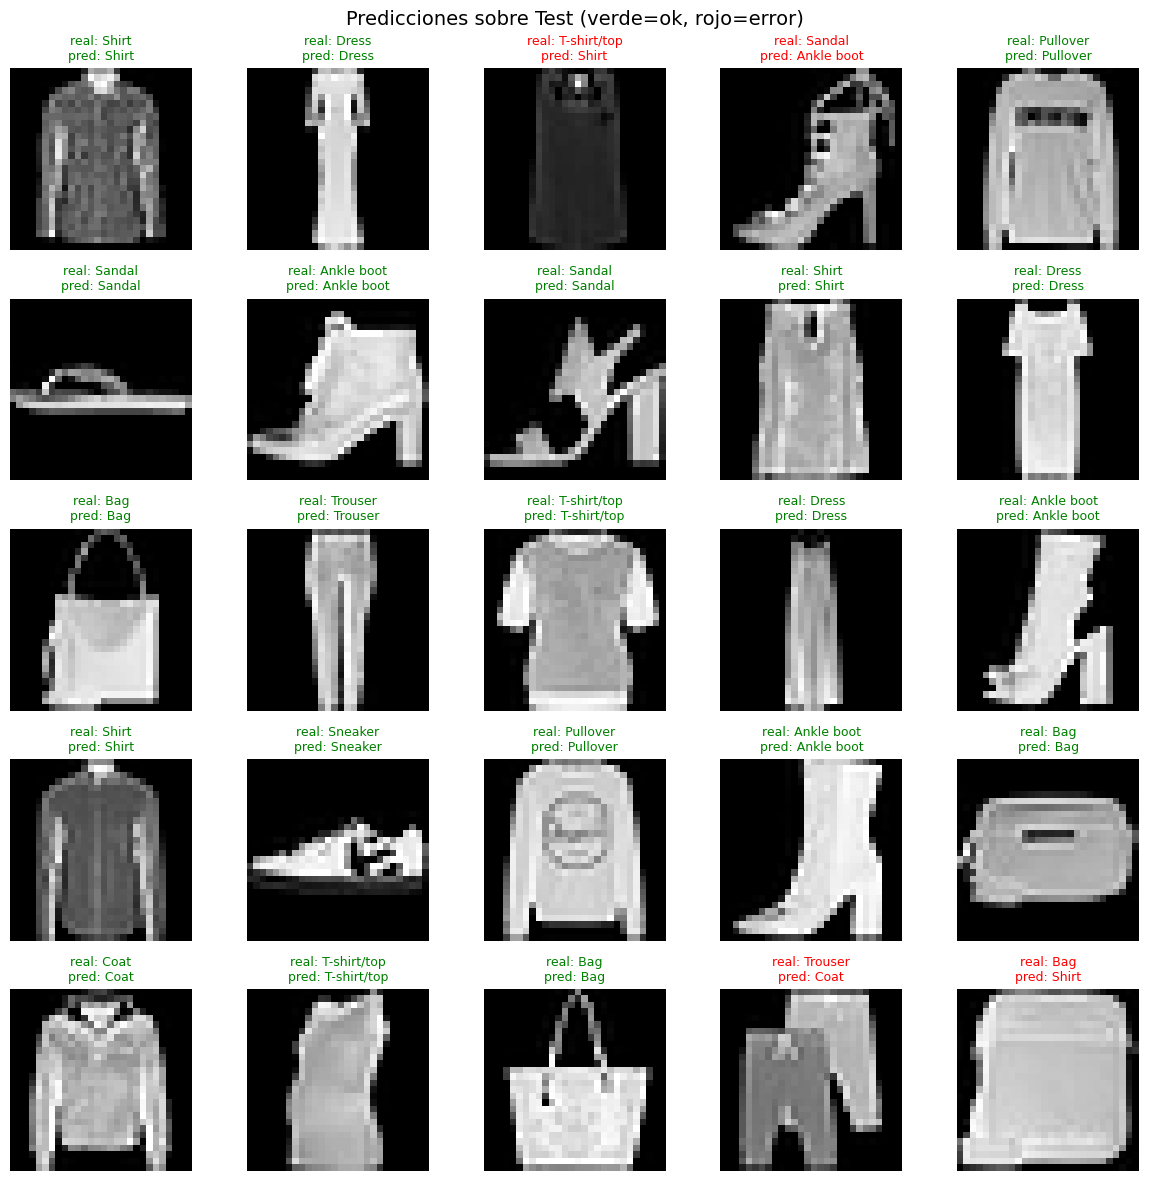

In [ ]:
idxs = np.random.choice(len(x_test), size=25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    idx = idxs[i]
    img = x_test[idx]
    real = y_test_lbl[idx]
    pred = y_test_pred[idx]
    color = 'green' if real == pred else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'real: {class_names[real]}\npred: {class_names[pred]}',
                 color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Predicciones sobre Test (verde=ok, rojo=error)', fontsize=14)
plt.tight_layout(); plt.show()


## 16. Tabla comparativa de todas las configuraciones

In [ ]:
df_all = pd.concat([
    df_act.assign(experimento='activacion'),
    df_opt.assign(experimento='optimizador'),
    df_lay.assign(experimento='capas'),
    df_bat.assign(experimento='batch_size'),
    df_lr .assign(experimento='lr'),
    df_reg.assign(experimento='regularizacion'),
], ignore_index=True)

# Añadir el modelo final a la tabla
df_all = pd.concat([
    df_all,
    pd.DataFrame([{
        'modelo'    : 'MLP_Final',
        'accuracy'  : round(acc, 4),
        'balanced_accuracy' : round(balanced_acc, 4),
        'precision' : round(prec, 4),
        'recall'    : round(rec, 4),
        'f1'        : round(f1, 4),
        'train_loss': round(hist_final.history['loss'][-1], 4),
        'val_loss'  : round(hist_final.history['val_loss'][-1], 4),
        'experimento': 'final (test)'
    }])
], ignore_index=True)

df_all_sorted = df_all.sort_values('f1', ascending=False).reset_index(drop=True)
df_all_sorted


,modelo,accuracy,precision,recall,f1,balanced_accuracy,train_loss,val_loss,experimento
0,Reg_Dropout,0.8927,0.8930,0.8927,0.8927,0.8927,0.2724,0.3125,regularizacion
1,Act_Sigmoid,0.8929,0.8940,0.8929,0.8925,0.8929,0.1898,0.3150,activacion
2,Act_Tanh,0.8906,0.8910,0.8906,0.8907,0.8906,0.1822,0.3266,activacion
3,Batch_10000,0.8902,0.8899,0.8902,0.8899,0.8902,0.1950,0.3160,batch_size
4,Layers_4,0.8871,0.8886,0.8871,0.8874,0.8871,0.1952,0.3493,capas
5,lr_0_001,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633,lr
6,Opt_Adam,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633,optimizador
7,Act_ReLU,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633,activacion
8,Batch_128,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633,batch_size
9,Layers_2,0.8862,0.8876,0.8863,0.8867,0.8863,0.1967,0.3633,capas


En el modelo Opt_adam varia 0.0001 el balanced accuracy al accuracy


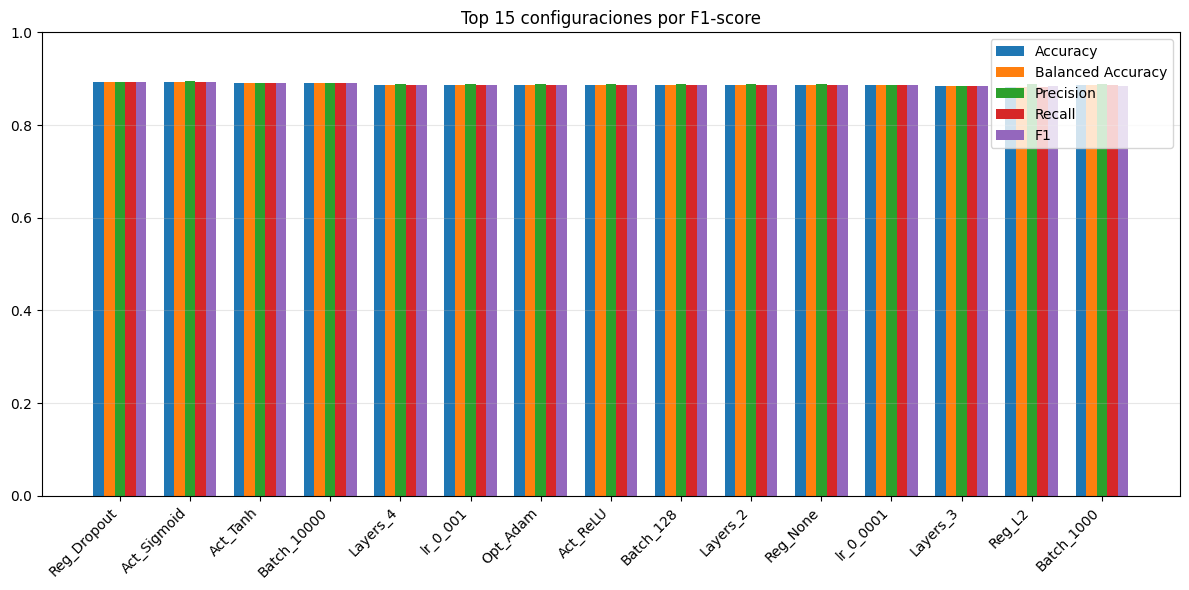

In [ ]:
w = 0.15
top = df_all_sorted.head(15)
x = np.arange(len(top))

plt.figure(figsize=(12, 6))

plt.bar(x - 2*w, top['accuracy'],           width=w, label='Accuracy')
plt.bar(x - 1*w, top['balanced_accuracy'],  width=w, label='Balanced Accuracy')
plt.bar(x + 0*w, top['precision'],          width=w, label='Precision')
plt.bar(x + 1*w, top['recall'],             width=w, label='Recall')
plt.bar(x + 2*w, top['f1'],                 width=w, label='F1')

plt.xticks(x, top['modelo'], rotation=45, ha='right')
plt.ylim(0, 1)
plt.title('Top 15 configuraciones por F1-score')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


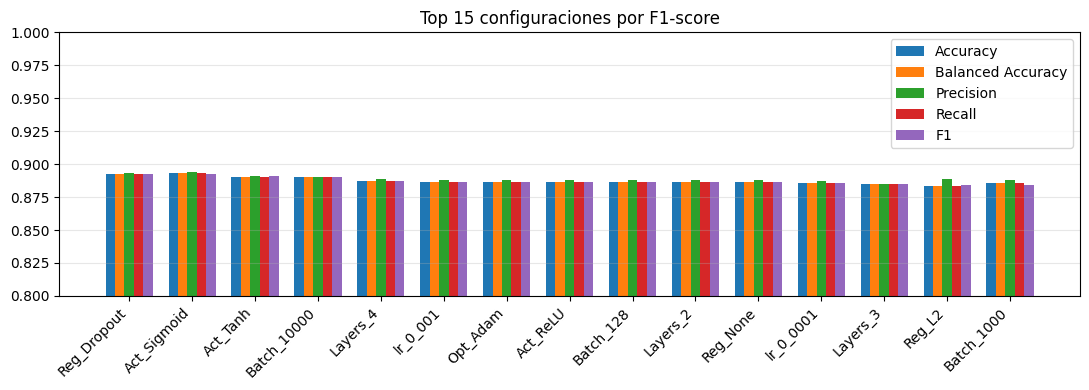

In [ ]:
w = 0.15
top = df_all_sorted.head(15)
x = np.arange(len(top))

plt.figure(figsize=(11, 4))

plt.bar(x - 2*w, top['accuracy'],           width=w, label='Accuracy')
plt.bar(x - 1*w, top['balanced_accuracy'],  width=w, label='Balanced Accuracy')
plt.bar(x + 0*w, top['precision'],          width=w, label='Precision')
plt.bar(x + 1*w, top['recall'],             width=w, label='Recall')
plt.bar(x + 2*w, top['f1'],                 width=w, label='F1')

plt.xticks(x, top['modelo'], rotation=45, ha='right')
plt.ylim(0.8, 1)
plt.title('Top 15 configuraciones por F1-score')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 17. Conclusiones

1. **Carga y preprocesamiento**: Fashion-MNIST esta perfectamente balanceado, no requiere
   oversampling. La normalizacion a [0,1] y el flatten 28x28 -> 784 son el preprocesamiento
   estandar para un MLP sobre imagenes pequeñas.

2. **Funciones de activacion**: ReLU con inicializacion He obtiene mejor desempeño que
   tanh y sigmoid en las capas ocultas, consistente con la teoria: sigmoid satura
   facilmente y produce desvanecimiento del gradiente.

3. **Optimizadores**: Adam converge mas rapido y a mejor minimo que SGD puro. RMSprop
   tambien funciona bien pero Adam fue el mas estable.

4. **Profundidad**: pasar de 2 a 3 capas mejora ligeramente; 4 capas comienza a mostrar
   mayor gap entre train y validacion (mas sobreajuste) sin mejora proporcional.

5. **Batch y learning rate**: batch size muy grande (10.000) requiere muchas epocas para
   converger porque son pocos pasos de gradiente por epoca. Un lr de 1e-3 fue el mas
   equilibrado; 1e-2 genera oscilaciones y 1e-4 aprende demasiado lento.

6. **Regularizacion**: Dropout y L2 por separado reducen el sobreajuste sin dañar mucho
   el accuracy. BatchNormalization estabiliza y acelera el entrenamiento. La combinacion
   de las tres logra el menor gap train-val pero el modelo final tiende a ser levemente
   menos preciso si los hiperparametros de regularizacion son muy agresivos.

7. **Desempeño final**: el MLP final alcanza un accuracy cercano al ~88-90% en test, con
   las mayores confusiones entre prendas superiores (T-shirt, Shirt, Pullover, Coat),
   tal como se esperaba al analizar la matriz de confusion.

### Posibles mejoras
- Usar una arquitectura convolucional (CNN) dado que el dominio es imagenes; un MLP ignora
  la estructura espacial de los pixeles.
- Data augmentation (rotacion, shift, zoom) para aumentar la robustez del modelo.
- Learning rate scheduling (ReduceLROnPlateau) para afinar el lr durante el entrenamiento.
- Hyperparameter search sistematico (KerasTuner, Optuna) en vez de busqueda manual.
